# EW4 data - GPM IMERG - Training an Autoencoder
This notebook explore the GPM IMERG dataset, including loading in PyEarthTools.

This dataset is a subset of the [NASA Integrated Multi-satellite Retrieval (IMERG)](https://gpm.nasa.gov/data/imerg) data for Global Precipitation Measurement (GPM). This subset has the following extents:
- Temporal Extent: April to September 2025
- Spatial Extent
  - Latitude 0N to 20N
  - Longitude 27W to 20E


### Import libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pathlib
import datetime
import functools
import math

In [5]:
import numpy

In [6]:
import xarray

In [7]:
import matplotlib
import cartopy.crs

In [8]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/tutorial_202606'}


In [9]:
import pyearthtools

In [10]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [11]:
from pyearthtools.data import Petdt, TimeDelta
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [12]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


In [13]:
import torch

## Loading the Data in PyEarthTools
Now we will load the data through the PyEarthTools data accessor. This is a class that has been created which how to access the data. For a dataset like this which is stored as files on disk, it specifries which files to load. Data could be loaded through other mechanisms though, for example it could be load from a database, through a web api, from a tape archive,  from a cloud-based object store or many other mechanisms.

We will take a look at the construction of the accessor, which can be found here:
* [IMERG Data Accessor](https://github.com/MetOffice/pyearthtools_jasmin/blob/main/src/site_archive_jasmin/ew4_imerg.py)
* [Template for Data Accessors](https://github.com/MetOffice/pyearthtools_jasmin/blob/main/src/site_archive_jasmin/template_accessor.py)

Further Reading 
* [PyEarthTools and Data Access](https://pyearthtools.readthedocs.io/en/latest/data.html)
* [Data Module Deep Dive Tutorials](https://pyearthtools.readthedocs.io/en/latest/notebooks/Gallery.html#Deep-Dive---The-Data-Module)


In [14]:
ew4_imerg_accessor = site_archive_jasmin.Ew4Imerg('2025-04-01 00:00', '2025-10-01 00:00')

In [15]:
ghana_extents = {
    'latitude': (4.7,11.1),
    'longitude': (-3.5, 2.9),
}


In [16]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][0],
                 ghana_extents['longitude'][1],
                )

In [63]:
ew4_gws_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')
ew4_gws_user_dir = ew4_gws_dir / 'user' / 'shaddad'
ew4_user_cache_dir = ew4_gws_user_dir / 'cache'
ew4_imerg_cache_dir = ew4_user_cache_dir / 'imerg'
imerg_norm_dir = ew4_imerg_cache_dir / 'norms'
ew4_imerg_ml_prepped_dir = ew4_imerg_cache_dir / 'ml_prepped'

## Train an ML model
To demonstrate how we can use this data in a machine learning training pipeline, we will show a simple autoencoder. We will first create the same pipeline that was created in the explore notebook. You should run the explore notebook first, so that the data is cached.

In [18]:
# ew4_imerg_prep = petpipe.Pipeline(
#     ew4_imerg_accessor,
#     petdata.transform.region.Bounding(*ghana_pet_box),
#     pyearthtools.pipeline.modifications.Cache(
#         ew4_imerg_cache_dir,
#         pattern_kwargs={'extension': 'nc'},
#         cache_validity='override',
#     ),
#     exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
# )

In [19]:
# ew4_imerg_ml = petpipe.Pipeline(
#     petpipe.operations.xarray.conversion.ToNumpy(),
#     petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
#     pyearthtools.pipeline.modifications.Cache( ml_cache_path,
#                                                pattern_kwargs={'extension': 'npy'},
#                                              )
# )


In [20]:
ew4_imerg_prep = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),
    pyearthtools.pipeline.modifications.Cache(
        ew4_imerg_cache_dir,
        pattern_kwargs={'extension': 'nc'},
        cache_validity='override',
    ),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [21]:
ew4_imerg_norm_segment = petpipe.Pipeline(
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=imerg_norm_dir),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


The last part is to convert to numpy arrays and cache those, so we can load the data as quickly as possible for training with pytorch.

In [22]:
ew4_imerg_ml = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    pyearthtools.pipeline.modifications.Cache( ew4_imerg_ml_prepped_dir,
                                               pattern_kwargs={'extension': 'npy'},
                                             ),
)

We now iterate through the data to calculate norms and populate the cache.

In [23]:
ew4_imerg_pipe = ew4_imerg_prep | ew4_imerg_norm_segment | ew4_imerg_ml

In [24]:
train_range = petpipe.Pipeline(
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250701T00', interval='1 hour').randomise(), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)
val_range = petpipe.Pipeline(
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250701T00', '20250801T00', interval='1 hour'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

Calculated indexes


In [28]:
ew4_imerg_train_pipe = ew4_imerg_pipe | train_range
ew4_imerg_val_pipe = ew4_imerg_pipe | val_range

In [30]:
numpy.histogram(ew4_imerg_val_pipe['2025-07-28 18:00'][0])

(array([4074,   15,    3,    0,    2,    0,    0,    1,    0,    1]),
 array([-0.22063448,  0.20499556,  0.6306256 ,  1.0562556 ,  1.4818857 ,
         1.9075158 ,  2.3331456 ,  2.7587757 ,  3.1844058 ,  3.610036  ,
         4.035666  ], dtype=float32))

## Set up autoencoder architecture

In [31]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### Determine the size of the filters around the latent space
One data dependant thing is to determine the size of the convolutional blocks either side of the latent space. We create some dummy layer to apply to our data to determine the size.

In [32]:
sample_tensor = torch.tensor(next(iter(ew4_imerg_train_pipe))[0][0], dtype=torch.float32).to(device)

In [33]:
sample_tensor

tensor([[[[-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206],
          [-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206],
          [-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206],
          ...,
          [-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206],
          [-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206],
          [-0.2206, -0.2206, -0.2206,  ..., -0.2206, -0.2206, -0.2206]]]],
       device='cuda:0')

In [34]:
sample_tensor.shape

torch.Size([1, 1, 64, 64])

In [35]:
numpy.histogram(next(iter(ew4_imerg_train_pipe))[0][0])

(array([4073,   13,    7,    2,    0,    0,    0,    0,    0,    1]),
 array([-0.22063448, -0.20622854, -0.1918226 , -0.17741665, -0.16301072,
        -0.14860478, -0.13419884, -0.1197929 , -0.10538696, -0.09098102,
        -0.07657509], dtype=float32))

In [36]:
torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, 
                            out_channels=16, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16, 
                            out_channels=32, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
).to(device)(sample_tensor).shape

torch.Size([1, 32, 16, 16])

### Create model class

In [37]:
class ImergAutoEncoder(torch.nn.Module):
    def __init__(self, input_channels, max_pool=False):
        super(ImergAutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        
        self._num_channels = [input_channels, 16,32]
        self._latent_array_dims = (-1,self._num_channels[-1],16,16)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        # self._latent_size = 500
        
        self._encoder = self._get_encoder(max_pool)
        self._decoder = self._get_decoder()

    def _get_encoder(self, max_pool):

        encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=self._num_channels[0], 
                            out_channels=self._num_channels[1], 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=self._num_channels[1], 
                            out_channels=self._num_channels[2], 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Flatten(1, -1),
            )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[2], out_channels=self._num_channels[1], kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[1], out_channels=self._num_channels[0], kernel_size=2,stride=2),
        )
        return decoder
        
    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))

        return reconstructed

In [38]:
# Initialize model and move to device
# ae_model = Era5AutoEncoder(wb_train_ds.num_channels, True).to(device)
imerg_autoencoder = ImergAutoEncoder(1, False).to(device)

It is useful at this point to ensure that we have correctly structured and dimensioned our layers by doing a forward pass on our data. If there is a mismatch between layers, we will find this error before we try to start training.

In [39]:
imerg_autoencoder._encoder(sample_tensor).view((-1,32,16,16))

tensor([[[[0.0370, 0.0856, 0.0856,  ..., 0.0856, 0.0856, 0.0856],
          [0.0000, 0.0325, 0.0325,  ..., 0.0325, 0.0325, 0.0325],
          [0.0000, 0.0325, 0.0325,  ..., 0.0325, 0.0325, 0.0325],
          ...,
          [0.0000, 0.0325, 0.0325,  ..., 0.0325, 0.0325, 0.0325],
          [0.0000, 0.0325, 0.0325,  ..., 0.0325, 0.0325, 0.0325],
          [0.0000, 0.0325, 0.0325,  ..., 0.0325, 0.0325, 0.0325]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0091, 0.0091,  ..., 0.0091, 0.0091, 0.0091],
          [0.0000, 0.0091, 0.0091,  ..., 0

In [40]:
sample_tensor.shape,imerg_autoencoder.forward(sample_tensor).shape

(torch.Size([1, 1, 64, 64]), torch.Size([1, 1, 64, 64]))

### Set up and run the training loop
Now we set up the loop to run gradient descent with back propogation to optimise the model weights of the autoencoder

In [41]:
# Loss function and optimizer
# loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(imerg_autoencoder.parameters(), 
                             lr=5e-3)

In [42]:
num_epochs = 25

In [43]:
num_samples = len(ew4_imerg_train_pipe)
batch_size=8
num_batches = math.ceil(num_samples / batch_size)
num_batches

183

In [44]:
def get_batch_tensors(batch_size, ds_iterator, device):
    """
    Get a torch tensor for target and predictors from a pyearthtools pipeline iterator
    """
    predictor_batch_list = []
    target_batch_list = []
    for _ in range(batch_size):
        pred_sample, target_sample = next(ds_iterator)
        predictor_batch_list += [pred_sample[0]]
        target_batch_list += [target_sample[0]]
    
    # create numpy array of a batch 
    predictor_array = numpy.concat(predictor_batch_list, axis=0)
    target_array = numpy.concat(target_batch_list, axis=0)
        
    # convert to a tensor and send to gpu
    predictor_gpu_tensor = torch.tensor(
        predictor_array,
        dtype=torch.float32,
    ).to(device)
    target_gpu_tensor = torch.tensor(
        target_array,
        dtype=torch.float32,
    ).to(device)    
    
    return predictor_gpu_tensor, target_gpu_tensor
        
    

To be sure of our model set up, run a forward pass with a batch to check it works as it did with a single sample

In [45]:
myit = iter(ew4_imerg_train_pipe)
imerg_autoencoder.forward(get_batch_tensors(batch_size, myit, device)[0]).shape, imerg_autoencoder.forward(get_batch_tensors(batch_size, myit, device)[0]).shape

(torch.Size([8, 1, 64, 64]), torch.Size([8, 1, 64, 64]))

In [46]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    imerg_train_iter = iter(ew4_imerg_train_pipe)
    
    for batch_ix in range(num_batches):

        predictor_gpu_tensor, target_gpu_tensor = get_batch_tensors(batch_size, imerg_train_iter, device)
        
        if (batch_ix % 100) == 0:
            print(batch_ix)

        # do training for batch
        optimizer.zero_grad()
        predictions = imerg_autoencoder.forward(predictor_gpu_tensor)
        loss_batch = loss_function(predictions, target_gpu_tensor)
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= num_batches

    # calculate loss on validation data    
    for val_predictor, val_target in ew4_imerg_val_pipe:
        val_pred_tensor = torch.tensor(val_predictor[0], dtype=torch.float32).to(device)
        predictions_val = imerg_autoencoder.forward( val_pred_tensor)
        val_target_tensor = torch.tensor(val_target[0], dtype=torch.float32).to(device)
        loss_batch_val = loss_function(predictions_val, val_target_tensor)
        epoch_val_loss += loss_batch_val.to('cpu').item()
    
    epoch_val_loss /= len(ew4_imerg_val_pipe)
    
    print(epoch_train_loss)
    print(epoch_val_loss)
        
        
        
        


0
0
100
0.04472265647637755
0.01685968519990227
1
0
100
0.012179401038402865
0.011403897775635023
2
0
100
0.007360190621327833
0.007012197278175248
3
0
100
0.005091523056623368
0.01100580828290643
4
0
100
0.003907853594180858
0.0025667147942693837
5
0
100
0.0020939696081907645
0.004005532351819115
6
0
100
0.003568975714749728
0.01496711125839029
7
0
100
0.0022442277615204137
0.0018864109288872612
8
0
100
0.0008396451511608609
0.0024771531513178287
9
0
100
0.001798237135278855
0.008147685147426968
10
0
100
0.0028144594612629966
0.002683453265299543
11
0
100
0.0008953752631235351
0.0011125911343931934
12
0
100
0.0007324561062534505
0.0010026002646554844
13
0
100
0.0006047574175989937
0.0010991063110547354
14
0
100
0.0005308987880208342
0.0007131881550688582
15
0
100
0.0007703516914729027
0.002532360259773404
16
0
100
0.0008722965291975119
0.001070738814095059
17
0
100
0.001014307174304261
0.0013101797910010607
18
0
100
0.0006593738108562608
0.0005590756495181385
19
0
100
0.00134836169947

## Evaluate results using Scores

In [47]:
import scores

In [48]:
val_rmse_list = []
for predictor, target in ew4_imerg_val_pipe:
    val_prediction_arr = imerg_autoencoder.forward(torch.tensor(predictor[0], dtype=torch.float32).to(device)).to("cpu").detach().numpy()
    val_rmse_list += [scores.continuous.rmse(predictor[0],
                                             val_prediction_arr)]

In [49]:
val_rmse = numpy.mean(val_rmse_list)

In [50]:
val_rmse

np.float32(0.01790193)

In [54]:
 predictor, target = ew4_imerg_val_pipe['2025-07-23 15:00']

In [55]:
pred_gpu = target_gpu = torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)
target_gpu = torch.tensor(
    target[0],
    dtype=torch.float32,
).to(device)

In [56]:
model_prediction_array = imerg_autoencoder.forward(torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)).to("cpu").detach().numpy()

Our model prediction will be output as a numpy array (after we've extracted it from pytorch tensor). We want to then reinstate the metadata so we can interact with the model predictions, for example showing plots. We can use the pipeline reverse functionality to reverse the to numpy operation and get an xarray dataset out.

In [57]:
norm_ml_segment = ew4_imerg_norm_segment | ew4_imerg_ml

In [58]:
input_ds = norm_ml_segment.reversed(predictor[0])
truth_ds = norm_ml_segment.reversed(target[0])
model_prediction = norm_ml_segment.reversed(model_prediction_array)

(array([2.000e+00, 4.000e+00, 6.000e+00, 7.200e+01, 3.789e+03, 2.080e+02,
        8.000e+00, 4.000e+00, 1.000e+00, 2.000e+00]),
 array([-0.19125274, -0.15017553, -0.10909832, -0.06802112, -0.02694391,
         0.0141333 ,  0.0552105 ,  0.09628773,  0.13736492,  0.17844212,
         0.21951935]),
 <BarContainer object of 10 artists>)

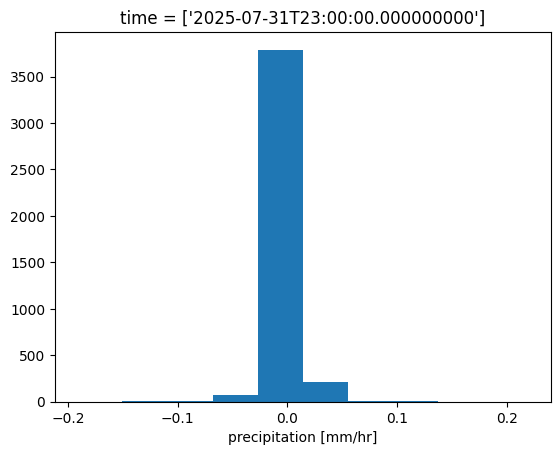

In [59]:
(model_prediction['precipitation'] - truth_ds['precipitation']).plot.hist()

In [60]:
plot_kwargs = {'cmap':'viridis', 'vmin':0.0, 'vmax':5.0}

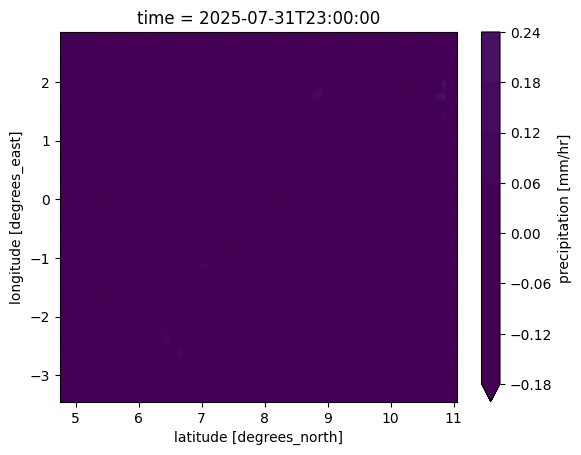

In [61]:
(model_prediction['precipitation'] - truth_ds['precipitation'])[0].plot.contourf(**plot_kwargs)

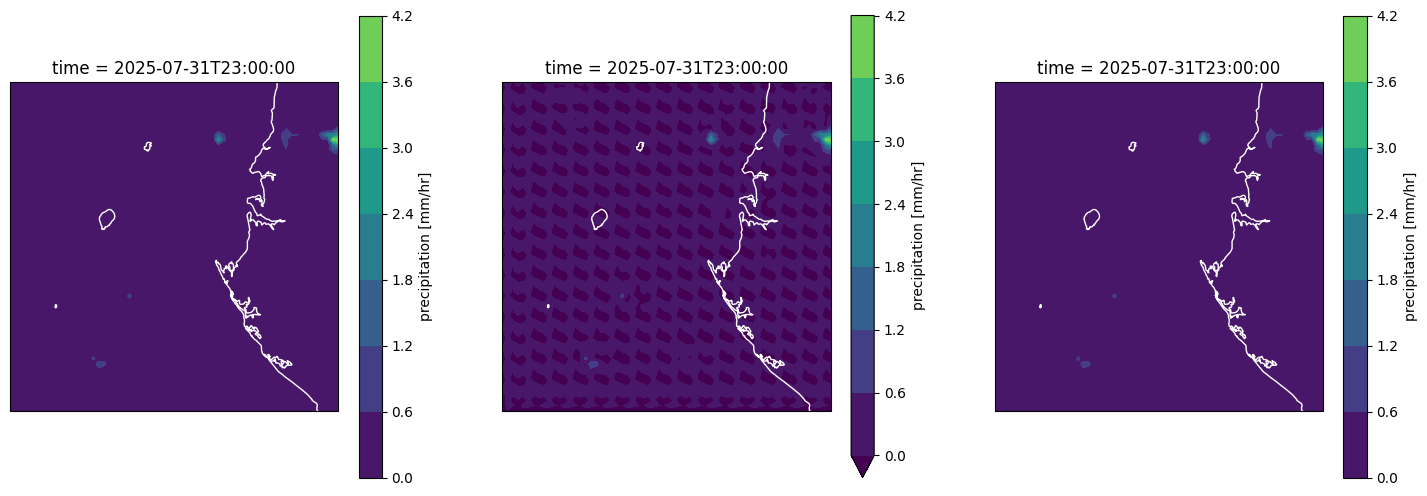

In [62]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))

ax1=fig1.add_subplot(1,3,1,projection=cartopy.crs.PlateCarree())
input_ds['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')

ax1=fig1.add_subplot(1,3,2,projection=cartopy.crs.PlateCarree())
model_prediction['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')


ax1=fig1.add_subplot(1,3,3,projection=cartopy.crs.PlateCarree())
truth_ds['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')


## Further Links

* [PyEarthTools Docs](https://pyearthtools.readthedocs.io/en/latest/)
  * [Tutorial Gallery](https://pyearthtools.readthedocs.io/en/latest/notebooks/Gallery.html)
* [PyEarthTools Repo](https://github.com/ACCESS-Community-Hub/PyEarthTools)
* [PyEarthTools JASMIN Site Archive Repo](https://github.com/MetOffice/pyearthtools_jasmin/)
*  [IMERG Dataset Info](https://gpm.nasa.gov/data/imerg)